In [1]:
# Read in library clusters from SLUG
import glob

# import numexpr as ne
import os
import re

import matplotlib.pyplot as plt
import numpy as np

In [8]:
prop= np.load('/g/data/jh2/jt4478/make_LC_copy/allprop_18Dec_final.npz.npy', allow_pickle=True).item()

In [12]:
np.shape(prop['mass'])

(800000,)

In [15]:
np.shape(prop['age'])[0]/10/500

160.0

In [19]:
det = np.load('/g/data/jh2/jt4478/make_LC_copy/detection_tset_13Jan.npy')
np.shape(det)

(500, 160, 10)

In [51]:
val_prop = np.load('/g/data/jh2/jt4478/make_LC_copy/all_prop_validation_tset_18Dec.npy', allow_pickle = True)

In [52]:
val_prop.item()

{'mass': array([775498.14927757,   2435.73211509,   3630.74857119, ...,
         48583.29624442, 971910.83826765, 108217.51201524]),
 'age': array([8.05953009e+05, 1.19126165e+07, 1.06595475e+07, ...,
        2.40818323e+07, 1.38309726e+10, 1.37801771e+10]),
 'av': array([2.61706074, 1.70762897, 1.49052631, ..., 1.1457981 , 2.16419855,
        2.93801608]),
 'phot': array([[18.81031928, 18.38211161, 19.22114106, 18.39069162, 17.02186721],
        [24.72275194, 24.54002328, 25.16968866, 24.35036362, 21.89363205],
        [23.76849861, 23.69683905, 24.53963759, 24.08152456, 22.20355202],
        ...,
        [21.07486426, 20.97860984, 21.58267234, 21.12175089, 19.84703196],
        [29.41765524, 26.92936388, 25.74818222, 24.16558317, 21.76636082],
        [33.08544154, 30.46558757, 29.06110408, 27.2732001 , 24.54219252]])}

In [74]:
mass = val_prop.item()['mass']

In [75]:
np.shape(logm )

(5000,)

In [76]:
np.shape(validation_det)

(500, 100, 10)

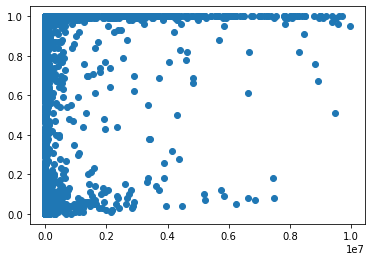

In [77]:
plt.scatter(mass, np.mean(validation_det, axis=1).flatten())

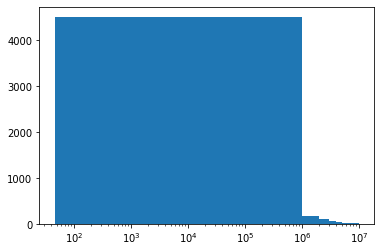

In [79]:
plt.hist(mass)
plt.xscale('log')

In [81]:
mass

array([5.88958077, 3.38662952, 3.55999618, ..., 4.68648698, 5.98762643,
       5.03429755])

In [82]:
mass=np.log10(mass)
y = np.mean(validation_det, axis=1).flatten()
x = mass
nbins = 20
bins = np.linspace(mass.min(), mass.max(), nbins + 1)
bin_idx = np.digitize(mass, bins) - 1

x_bin = [mass[bin_idx == i].mean() for i in range(nbins) if np.any(bin_idx == i)]
y_bin = [y[bin_idx == i].mean() for i in range(nbins) if np.any(bin_idx == i)]

plt.plot(x_bin, y_bin, "o-")

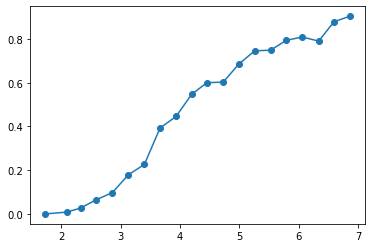

In [84]:
# make inference
import numpy as np

from nn_utils import *


ImportError: cannot import name 'deprecated' from 'typing_extensions' (/apps/jupyterlab/3.4.3-py3.9/lib/python3.9/site-packages/typing_extensions.py)

In [54]:
comp_bin_mean = np.full(nbin, np.nan)

for i in range(nbin):
    m = (logm >= bins[i]) & (logm < bins[i+1])
    if not m.any():
        continue

    # 取出该 bin 内所有 cluster
    # shape: (N_cluster_in_bin, 100, 10)
    comp_bin = comp[m, :, :]

    # 对 (trial, radii) flatten 再 mean
    comp_bin_mean[i] = np.nanmean(comp_bin)


IndexError: boolean index did not match indexed array along dimension 0; dimension is 500 but corresponding boolean dimension is 5000

In [44]:
import numpy as np

logm = np.log10(mass)

nbin = 20
bins = np.linspace(logm.min(), logm.max(), nbin + 1)
centers = 0.5 * (bins[:-1] + bins[1:])


In [45]:
mass

array([775498.14927757,   2435.73211509,   3630.74857119, ...,
        48583.29624442, 971910.83826765, 108217.51201524])

In [46]:
comp_bin_mean

array([0.445     , 0.38273063, 0.388225  , 0.40220994, 0.38716216,
       0.39525253, 0.40768328, 0.40934579, 0.41612121, 0.41776699,
       0.42130268, 0.41214286, 0.42655738, 0.42051813, 0.4326484 ,
       0.43335079, 0.41287356, 0.42662252, 0.43311475, 0.44411111])

In [35]:
centers

array([1.79295431, 2.05988747, 2.32682062, 2.59375377, 2.86068692,
       3.12762008, 3.39455323, 3.66148638, 3.92841953, 4.19535268,
       4.46228584, 4.72921899, 4.99615214, 5.26308529, 5.53001845,
       5.7969516 , 6.06388475, 6.3308179 , 6.59775105, 6.86468421])

In [36]:
comp_bin_mean

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan])

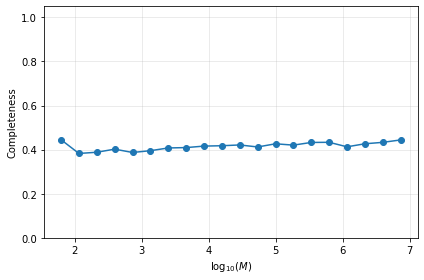

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(centers, comp_bin_mean, marker='o')
plt.xlabel(r'$\log_{10}(M)$')
plt.ylabel('Completeness')
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [2]:
main_dir = "/g/data/jh2/jt4478/make_LC_copy"
os.chdir(main_dir)
# define constants
processes = []
PSFpath = '/g/data/jh2/jt4478/PSF_all'
baopath = '/g/data/jh2/jt4478/baolab-0.94.1g/'
galaxies = np.load(os.path.join(main_dir, 'galaxy_names.npy'))
gal_filters = np.load('galaxy_filter_dict.npy', allow_pickle=True).item()
nsf =  True
pixscale_wfc3 = 0.04
pixscale_acs = 0.05
# maglim = array([18, 26], dtype=float)
merr_cut = 0.3 # change to 0.5
binsize = 0.3
nums_perframe = 500
sigma_pc = 100 # physical size of Gaussian filter for distributing clusters on sci frame
xcol=0            #specifies which column in the data contains the x-coordinates
ycol=1            #specifies which column in the data contains the x-coordinates
tolerance = 3 # tolerance in units of px, testing 5 pixels
minsep = False
maglim = [18,26]
cams = gal_filters['ngc628-c']
minsep = False
nsf=True
use_white_pos = True
white_dir = '/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100/white'

In [3]:
# 1. Deteced in white (use sex...coo for coordiantes comparison to flag detection)
# 2. Detected in ≥ 4 bands with error < 0.3 mag. (Except V band, use /photomety folder .coo files to get coordinates + mag _errr, pass these two, flag detection), needs V band magnitudes Brighter than MV = –6 mag (CI-based V-band).

In [3]:
import os

import numpy as np
from scipy.spatial import cKDTree

# Constants
nframe_start = 0
nframe_end   = 100
nframe       = nframe_end - nframe_start
reff         = 10
x_white      = 500
thres_coor   = 3
outname      = "tset_16Dec"
validation   = True

# Output
detection_white = np.zeros((x_white, nframe, reff), dtype=np.uint8)
detected_index  = {}              # (frame, re) -> indices of detected synthetic
syn_cache       = {}              # NEW: cache syn coords for part2

# Directories
sex_dir   = "/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100/white/s_extraction"
white_dir = "/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100/white"

for re in range(1, reff+1):
    for f in range(nframe_start, nframe_end):

        sex_pattern = f"sex_ngc628-c_WFC3_UVISfF336W_frame{f}_{outname}_reff{re:.2f}.fits.coo"
        sex_files = glob.glob(os.path.join(sex_dir, sex_pattern))
        if len(sex_files) != 1:
            print(f"[WARN] ambiguous/no SEX file for frame={f} reff={re}")
            continue

        syn_pattern = f"white_position_{f}_{outname}_reff{re:.2f}.txt"
        syn_files = glob.glob(os.path.join(white_dir, syn_pattern))
        if len(syn_files) != 1:
            print(f"[WARN] ambiguous/no SYN file for frame={f} reff={re}")
            continue

        sex_c = np.loadtxt(sex_files[0])
        syn_c = np.loadtxt(syn_files[0])

        if sex_c.ndim == 1:
            sex_c = sex_c.reshape(1, -1)
        if syn_c.ndim == 1:
            syn_c = syn_c.reshape(1, -1)

        # --- enforce 500 clusters ---
        assert syn_c.shape[0] == x_white, f"syn_c != 500 for (f={f}, re={re})"

        # cache syn for part 2
        syn_cache[(f,re)] = syn_c

        # KDTree match
        tree = cKDTree(sex_c[:, :2])
        dist, idx = tree.query(syn_c[:, :2], distance_upper_bound=thres_coor)
        mask = np.isfinite(dist) & (dist < thres_coor)

        detection_white[:, f, re-1] = mask.astype(np.uint8)
        detected_index[(f, re)] = np.where(mask)[0]

print("White detection done:", detection_white.shape)
np.save(f"detection_white_{outname}_validation.npy", detection_white)
np.save(f"DETECTED_INDEX_{outname}_validation.npy", detected_index)
# np.save("SYN_CACHE.npy", syn_cache)   # NEW


White detection done: (500, 100, 10)


In [48]:
import glob
import os

import numpy as np
from scipy.spatial import cKDTree

filters = ["f275w", "f336w", "f435w", "f555w", "f814w"]
nf      = len(filters)

nframe  = 10
reff    = 10
x_white = 500
main_dir = "/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100"
outname = "vset_17Nov"

detected_index = np.load("DETECTED_INDEX.npy", allow_pickle=True).item()
syn_cache      = np.load("SYN_CACHE.npy", allow_pickle=True).item()  # NEW

detection_filters = np.zeros((x_white, nframe, reff), dtype=np.uint8)

# magnitude QC
D_MOD  = 29.98
MV_cut = -6
V_LIMIT = D_MOD + MV_cut

for re in range(1, reff+1):
    for f in range(nframe):

        syn_ids = detected_index.get((f, re), np.array([], dtype=int))
        if syn_ids.size == 0:
            continue

        # guaranteed consistent with white detection
        syn_c = syn_cache[(f, re)]
        assert syn_c.shape[0] == x_white

        good = np.zeros((len(syn_ids), nf), dtype=np.uint8)

        for j, filt in enumerate(filters):

            if filt != "f555w":
                pattern = f"{filt}/photometry/coo_ngc628-c*{filt}_frame{f}_{outname}_reff{re:.2f}.fits.coo"
            else:
                pattern = f"{filt}/CI/ci_cut_*ngc628-c*{filt}_frame{f}_{outname}_reff{re:.2f}.fits.coo"

            files = glob.glob(os.path.join(main_dir, pattern))
            if len(files) != 1:
                print(f"[WARN] ambiguous/no {filt} file for frame={f}, reff={re}")
                continue

            sex_c = np.loadtxt(files[0])
            if sex_c.ndim == 1:
                sex_c = sex_c.reshape(1, -1)

            tree = cKDTree(sex_c[:, :2])
            query_pos = syn_c[syn_ids, :2]
            dist, idx = tree.query(query_pos, distance_upper_bound=3)

            detect_mask = np.isfinite(dist) & (dist < 3)

            if detect_mask.any():
                mags = sex_c[idx[detect_mask], 2]
                magerr = sex_c[idx[detect_mask], 3]

                qc = (magerr <= 0.3)
                if filt == "f555w":
                    qc &= (mags < V_LIMIT)

                detect_mask[detect_mask] &= qc

            good[:, j] = detect_mask.astype(np.uint8)

        detection_filters[syn_ids, f, re-1] = (good.sum(axis=1) >= 4).astype(np.uint8)

np.save("detection_filters.npy", detection_filters)
print("✔ detection_filters shape =", detection_filters.shape)


[WARN] ambiguous/no f814w file for frame=0, reff=1
[WARN] ambiguous/no f814w file for frame=1, reff=1
[WARN] ambiguous/no f814w file for frame=2, reff=1
[WARN] ambiguous/no f814w file for frame=3, reff=1
[WARN] ambiguous/no f814w file for frame=4, reff=1
[WARN] ambiguous/no f814w file for frame=5, reff=1
[WARN] ambiguous/no f814w file for frame=6, reff=1
[WARN] ambiguous/no f814w file for frame=7, reff=1
[WARN] ambiguous/no f814w file for frame=8, reff=1
[WARN] ambiguous/no f814w file for frame=9, reff=1
[WARN] ambiguous/no f814w file for frame=0, reff=2
[WARN] ambiguous/no f814w file for frame=1, reff=2
[WARN] ambiguous/no f814w file for frame=2, reff=2
[WARN] ambiguous/no f814w file for frame=3, reff=2
[WARN] ambiguous/no f814w file for frame=4, reff=2
[WARN] ambiguous/no f814w file for frame=5, reff=2
[WARN] ambiguous/no f814w file for frame=6, reff=2
[WARN] ambiguous/no f814w file for frame=7, reff=2
[WARN] ambiguous/no f814w file for frame=8, reff=2
[WARN] ambiguous/no f814w file 

In [12]:
import glob
import os

import numpy as np
from scipy.spatial import cKDTree

# Constants
nframe_start = 0
nframe_end = 160
nframe = nframe_end - nframe_start
reff = 10
x_white = 500
thres_coor = 3
outname = "tset_16Dec"
validation = False

# Output matrices
detection_white = np.zeros((x_white, nframe, reff), dtype=np.uint8)
detected_index = {}  # (frame, re) → synthetic index list

# Directories
sex_dir = "/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100/white/s_extraction"
white_dir = "/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100/white"
matched_out = os.path.join(white_dir, "matched_coords")
os.makedirs(matched_out, exist_ok=True)

for re in range(1, reff + 1):
    for f in range(nframe_start, nframe_end):

        # ---- SEXTRACTOR COORD FILE ----
        if not validation:
            sex_pattern = (
                f"sex_ngc628-c_WFC3_UVISfF336W_frame{f}_{outname}_reff{re:.2f}.fits.coo"
            )

        sex_files = glob.glob(os.path.join(sex_dir, sex_pattern))

        # ---- synthetic positions ----
        if not validation:
            syn_pattern = f"white_position_{f}_{outname}_reff{re:.2f}.txt"

        syn_files = glob.glob(os.path.join(white_dir, syn_pattern))

        if not sex_files or not syn_files:
            continue

        sex_c = np.loadtxt(sex_files[0])
        syn_c = np.loadtxt(syn_files[0])

        # Extract positions
        x_v, y_v = sex_c[:, 0], sex_c[:, 1]
        x_s, y_s = syn_c[:, 0], syn_c[:, 1]

        # KDTree match
        tree = cKDTree(np.column_stack((x_v, y_v)))
        dist, idx = tree.query(np.column_stack((x_s, y_s)), distance_upper_bound=thres_coor)

        mask = np.isfinite(dist) & (dist < thres_coor)
        detection_white[:, f, re - 1] = mask.astype(np.uint8)

        # Save detected synthetic indices
        detected_index[(f, re)] = np.where(mask)[0]

print("White detection done:", detection_white.shape)
np.save(f"detection_white_{outname}.npy", detection_white)
np.save(f"DETECTED_INDEX_{outname}.npy", detected_index)


White detection done: (500, 10, 10)


In [11]:
import glob
import os

import numpy as np
from scipy.spatial import cKDTree

filters = ["f275w", "f336w", "f435w", "f555w", "f814w"]
nf = len(filters)

# Constants
nframe = 10
reff = 10
x_white = 500
validation = False
main_dir = "/g/data/jh2/jt4478/make_LC_copy/ngc628-c_white-R17v100"

# # Load white index mapping
# detected_index = np.load("DETECTED_INDEX.npy", allow_pickle=True).item()

# Output matrix
detection_filters = np.zeros((x_white, nframe, reff), dtype=np.uint8)

# Absolute magnitude cut
D_MOD = 29.98
MV_cut = -6
V_LIMIT = D_MOD + MV_cut

for re in range(1, reff + 1):
    for f in range(nframe):

        # Synthetic IDs detected from Step 1
        syn_ids = detected_index.get((f, re), np.array([], dtype=int))
        if len(syn_ids) == 0:
            continue

        # Load synthetic coords again
        if not validation:
            syn_file = glob.glob(
                os.path.join(main_dir, "white",
                    f"white_position_{f}_{outname}_reff{re:.2f}.txt")
            )[0]
        syn_c = np.loadtxt(syn_file)
        x_s, y_s = syn_c[:, 0], syn_c[:, 1]

        # Track good filters
        good = np.zeros((len(syn_ids), nf), dtype=np.uint8)

        for j, filt in enumerate(filters):

            # Find filter SEX coo file
            if filt != "f555w":
                pattern = f"{filt}/photometry/coo_ngc628-c*{filt}_frame{f}_{outname}_reff{re:.2f}.fits.coo"
            else:
                pattern = f"{filt}/CI/ci_cut_*ngc628-c*{filt}_frame{f}_{outname}_reff{re:.2f}.fits.coo"

            files = glob.glob(os.path.join(main_dir, pattern))
            if not files:
                continue

            sex_c = np.loadtxt(files[0])
            if sex_c.ndim == 1:
                sex_c = sex_c[None, :]

            # Build KDTree for matching
            tree = cKDTree(sex_c[:, :2])

            # Only match synthetic that were detected in white
            query_pos = syn_c[syn_ids, :2]
            dist, idx = tree.query(query_pos, distance_upper_bound=3)

            # Valid detections
            detect_mask = np.isfinite(dist) & (dist < 3)

            # Magnitude QC
            if detect_mask.any():
                mags = sex_c[idx[detect_mask], 2]
                magerr = sex_c[idx[detect_mask], 3]

                qc = magerr <= 0.3

                if filt == "f555w":
                    qc &= (mags < V_LIMIT)

                detect_mask[detect_mask] &= qc

            # Save into good filters array
            good[:, j] = detect_mask.astype(np.uint8)

        # Good if ≥ 4 filters
        N_good = good.sum(axis=1)
        detection_filters[syn_ids, f, re - 1] = (N_good >= 4).astype(np.uint8)

np.save("detection_filters.npy", detection_filters)
print("✔ detection_filters shape =", detection_filters.shape)


✔ detection_filters shape = (500, 10, 10)


In [49]:
# detection_white = np.load("detection_white.npy")
# detection_filters = np.load("detection_filters.npy")

final_detection = (detection_white & detection_filters).astype(np.uint8)
np.save("final_detection.npy", final_detection)

print("Final completeness cube:", final_detection.shape)

Final completeness cube: (500, 10, 10)


In [6]:
np.shape(final_detection)

(500, 100, 10)

In [8]:
detections_reff = {}
for i in range(1, 11):
    detections_reff[i] = np.concatenate(final_detection[:,:,i-1])



In [50]:
def load_prop(prefix, reff, max_frame=10):
    arr_list = []
    for i in range(max_frame):
        fname = os.path.join(path_npy, f"{prefix}*frame{i}_reff{reff}_{outname}.npy")
        files = sorted(glob.glob(fname))
        if len(files) != 1:
            raise RuntimeError(f"Missing or multiple files for: {fname}")
        arr = np.load(files[0])
        arr_list.append(arr)
    # guarantee correct order
    return np.concatenate(arr_list, axis=0)


In [31]:
mass_all[reff] = load_prop("mass", reff)
age_all[reff]  = load_prop("age", reff)
av_all[reff]   = load_prop("av", reff)
mag_all[reff]  = load_prop("mag_VEGA_", reff)   # shape (5000, nf)


ValueError: setting an array element with a sequence.

In [9]:
np.save('detections_all_27Nov.npz', detections_reff)

In [52]:
# Next step check if vset and tset have any overlapping clusters

In [53]:
path_npy = '/g/data/jh2/jt4478/make_LC_copy/physprop'
# NEXT check: plot mass versus detection for validation sets
mass_check_matrix = np.zeros((500, nframe, 10))
nframe = 100
for reff in range(1, 11):
    for i in range(nframe):
        mass_check_files = glob.glob(os.path.join(path_npy, f'mass*flat_frame{i}_reff{reff}_{outname}.npy'))
        mass_check = np.load(mass_check_files[0])
        mass_check_matrix[:, i, int(reff-1)] = mass_check

In [54]:
mass_check_files

['/g/data/jh2/jt4478/make_LC_copy/physprop/mass_select_modelflat_frame99_reff10_tset_13Nov.npy']

In [55]:
np.shape(mass_check_matrix)

(500, 100, 10)

In [7]:
np.shape(final_detection)

(500, 100, 10)

In [1]:
import glob
import os

import numpy as np

outname = "tset_18Dec"
path_npy = "/g/data/jh2/jt4478/make_LC_copy/physprop"

MAX_REFF = 10
MAX_FRAME = 160
CLUSTERS_PER_FRAME = 500

mass_all = {}
age_all  = {}
av_all   = {}
mag_all  = {}

def load_one_file(pattern):
    """Expect exactly one file. Raise error otherwise."""
    files = glob.glob(pattern)
    if len(files) != 1:
        raise RuntimeError(f"Expected 1 file, found {len(files)}: {pattern}")
    return np.load(files[0])

for reff in range(1, MAX_REFF + 1):

    mass_list = []
    age_list  = []
    av_list   = []
    mag_list  = []

    for frame in range(MAX_FRAME):

        # ---------- MASS ----------
        mass_pattern = os.path.join(
            path_npy,
            f"mass*modelKrumholz19_frame{frame}_reff{reff}_{outname}.npy"
        )
        mass_arr = load_one_file(mass_pattern).ravel()
        if mass_arr.size != CLUSTERS_PER_FRAME:
            raise RuntimeError(f"mass size != 500 at frame {frame}, reff {reff}")
        mass_list.append(mass_arr)

        # ---------- AGE ----------
        age_pattern = os.path.join(
            path_npy,
            f"age*Krumholz19_frame{frame}_reff{reff}_{outname}.npy"
        )
        age_arr = load_one_file(age_pattern).ravel()
        if age_arr.size != CLUSTERS_PER_FRAME:
            raise RuntimeError(f"age size != 500 at frame {frame}, reff {reff}")
        age_list.append(age_arr)

        # ---------- AV ----------
        av_pattern = os.path.join(
            path_npy,
            f"av*Krumholz19_frame{frame}_reff{reff}_{outname}.npy"
        )
        av_arr = load_one_file(av_pattern).ravel()
        if av_arr.size != CLUSTERS_PER_FRAME:
            raise RuntimeError(f"av size != 500 at frame {frame}, reff {reff}")
        av_list.append(av_arr)

        # ---------- MAG ----------
        mag_pattern = os.path.join(
            path_npy,
            f"mag_VEGA_*Krumholz19_frame{frame}_reff{reff}_{outname}.npy"
        )
        mag_arr = load_one_file(mag_pattern)
        if mag_arr.shape[0] != CLUSTERS_PER_FRAME:
            raise RuntimeError(f"mag rows != 500 at frame {frame}, reff {reff}")
        mag_list.append(mag_arr)

    # concatenate in strictly ordered (frame0, frame1, ..., frame9)
    mass_all[reff] = np.concatenate(mass_list, axis=0)     # shape = (5000,)
    age_all[reff]  = np.concatenate(age_list,  axis=0)     # shape = (5000,)
    av_all[reff]   = np.concatenate(av_list,   axis=0)     # shape = (5000,)
    mag_all[reff]  = np.concatenate(mag_list,  axis=0)     # shape = (5000, nf)


all_phys = {}
all_phys['mass'] = mass_all
all_phys['age'] = age_all
all_phys['av'] = av_all
all_phys['phot'] = mag_all
np.save('allprop_tset_18Dec.npz', all_phys)

✔ physprop saving finished (frame-aligned).


In [60]:
np.shape(final_detection)

(500, 10, 10)

In [54]:
final_detection_ = final_detection.flatten()
mass_check_ = all_phys['mass']

In [55]:
mc = []
for i in range(1, 11):
    mc.append(mass_check_[i])


In [56]:
mass_all = np.concatenate(mc)
mass_check_ = mass_all

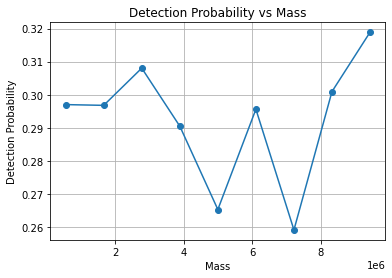

In [58]:
from scipy.stats import binned_statistic

bins = np.linspace(mass_check_.min(), mass_check_.max(), 10)

detection_prob, edges, _ = binned_statistic(
    mass_check_, final_detection_, statistic="mean", bins=bins
)

bin_centers = 0.5 * (edges[:-1] + edges[1:])

plt.plot(bin_centers, detection_prob, marker='o')
plt.xlabel("Mass")
plt.ylabel("Detection Probability")
plt.title("Detection Probability vs Mass")
plt.grid(True)
plt.show()


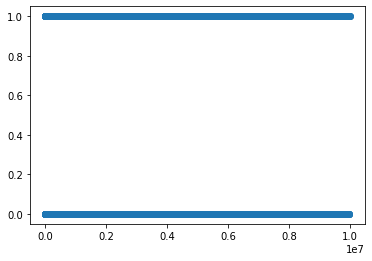

In [46]:
plt.scatter(mass_check_, final_detection_)

In [5]:
# next step: save the phys and photometric properties to a dict
# we need to shuffle all radii to have this test